In [1]:
import os
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

In [2]:
# Checking Device/confirming it works with CUDA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


In [3]:
# Helper Functions

def subset_dataset(dataset, percent, seed=6050):
    if percent >= 1.0:
        return dataset
    
    random.seed(seed)
    subset_size = int(len(dataset) * percent)
    indices = random.sample(range(len(dataset)), subset_size)
    return Subset(dataset, indices)

def plot_loss_and_acc(track_loss, track_train_acc, track_val_acc):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(track_train_acc, label="Train")
    plt.plot(track_val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(track_loss, label="Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [4]:
# CONFIGURATION

data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")  # adjust as needed
train_dir = data_root / "train"
val_dir = data_root / "validation"

batch_size = 32
num_workers = 4
num_epochs = 5
learning_rate = 1e-4
train_percent = 0.5  # train/validate on 50% of data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# DATA TRANSFORMS

transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize for ResNet
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

'''
resize will resize the image to 256x256
randomcrop will random crop a 224x224 image from the 256x256 image
randomhorizontalflip will randomly flip the image horizontally

toTensor will convert the image to a tensor
normalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on

'''

'\nresize will resize the image to 256x256\nrandomcrop will random crop a 224x224 image from the 256x256 image\nrandomhorizontalflip will randomly flip the image horizontally\n\ntoTensor will convert the image to a tensor\nnormalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on\n\n'

In [6]:
# dataloader loads alphabetically, so we need to swap labels
class CustomImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        # Swap label: make 'real' = 0, 'fake' = 1
        label = 1 - label
        return img, label

In [7]:
# LOAD DATASETS

train_dataset = CustomImageFolder(root=str(train_dir), transform=transform)
val_dataset = CustomImageFolder(root=str(val_dir), transform=transform)

print("Original class mapping:", train_dataset.class_to_idx)  # still 'fake':0, 'real':1

# train_dataset = subset_dataset(train_dataset, train_percent)
# val_dataset = subset_dataset(val_dataset, train_percent)

#DATALOADERS
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Training on {len(train_dataset)} images, validating on {len(val_dataset)} images.")

Original class mapping: {'fake': 0, 'real': 1}
Training on 115200 images, validating on 28340 images.


In [8]:
# --- Paths to your fake CSVs (adjust names/paths as needed) ---
train_fake_csv_path = r'C:/Users/Jimmy/OneDrive/Desktop/ID_of_AI_Images/temporal_validation/fake_train_temporal_splits.csv'
val_fake_csv_path   = r'C:/Users/Jimmy/OneDrive/Desktop/ID_of_AI_Images/temporal_validation/fake_validation_temporal_splits.csv'

train_fake_df = pd.read_csv(train_fake_csv_path)
val_fake_df   = pd.read_csv(val_fake_csv_path)

# Ensure filename column is just the basename (in case it has paths)
train_fake_df["filename"] = train_fake_df["filename"].apply(os.path.basename)
val_fake_df["filename"]   = val_fake_df["filename"].apply(os.path.basename)

# Map: filename -> window
train_file_to_window = dict(zip(train_fake_df["filename"], train_fake_df["w_split"]))
val_file_to_window   = dict(zip(val_fake_df["filename"],   val_fake_df["w_split"]))

# Determine max window index
max_train_w = train_fake_df["w_split"].max()
max_val_w   = val_fake_df["w_split"].max()
max_w       = int(max(max_train_w, max_val_w))

print(f"Max window index detected: {max_w}")

Max window index detected: 8


In [10]:
# --- Per-window fake indices for train/val ---
train_fake_indices_by_w = {w: [] for w in range(max_w + 1)}
val_fake_indices_by_w   = {w: [] for w in range(max_w + 1)}

# --- Real indices (used at all steps) ---
train_real_indices = []
val_real_indices   = []

FAKE_CLASS = train_dataset.class_to_idx["fake"]  # 0
REAL_CLASS = train_dataset.class_to_idx["real"]  # 1

# Build train indices
for idx, (path, cls) in enumerate(train_dataset.samples):
    fname = os.path.basename(path)
    if cls == REAL_CLASS:
        train_real_indices.append(idx)
    elif cls == FAKE_CLASS:
        if fname in train_file_to_window:
            w = int(train_file_to_window[fname])
            train_fake_indices_by_w[w].append(idx)
        else:
            # Optional: warn if some fake images don't have a window
            print(f"[WARN] Train fake missing from CSV: {fname}")

# Build val indices
for idx, (path, cls) in enumerate(val_dataset.samples):
    fname = os.path.basename(path)
    if cls == REAL_CLASS:
        val_real_indices.append(idx)
    elif cls == FAKE_CLASS:
        if fname in val_file_to_window:
            w = int(val_file_to_window[fname])
            val_fake_indices_by_w[w].append(idx)
        else:
            print(f"[WARN] Val fake missing from CSV: {fname}")

print("Train real:", len(train_real_indices))
for w in range(max_w + 1):
    print(f"Train fake w{w}: {len(train_fake_indices_by_w[w])}")

print("Val real:", len(val_real_indices))
for w in range(max_w + 1):
    print(f"Val fake w{w}: {len(val_fake_indices_by_w[w])}")


Train real: 57600
Train fake w0: 6364
Train fake w1: 6455
Train fake w2: 6501
Train fake w3: 6385
Train fake w4: 6268
Train fake w5: 6411
Train fake w6: 6370
Train fake w7: 6387
Train fake w8: 6459
Val real: 14170
Val fake w0: 1545
Val fake w1: 1604
Val fake w2: 1524
Val fake w3: 1570
Val fake w4: 1600
Val fake w5: 1594
Val fake w6: 1559
Val fake w7: 1587
Val fake w8: 1587


In [12]:
def make_loader_for_windows(
    dataset,
    real_indices,
    fake_indices_by_w,
    windows,
    batch_size,
    shuffle,
    num_workers=0
):
    all_indices = list(real_indices)
    for w in windows:
        all_indices.extend(fake_indices_by_w[w])
    subset = Subset(dataset, all_indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
    return loader, len(all_indices)


In [9]:
subset = train_dataset

for idx in range(10):
    if isinstance(subset, torch.utils.data.Subset):
        actual_idx = subset.indices[idx]
        img, label = subset[idx]
        path = subset.dataset.imgs[actual_idx][0]
    else:
        img, label = subset[idx]
        path = subset.imgs[idx][0]

    print(f"{path} --> Label: {label}")

C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000001.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000002.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000003.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000004.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000006.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000008.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000012.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000013.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000014.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000017.png --> Label: 1


In [13]:
# MODEL SETUP (ResNet50)

model = models.resnet50(weights=True)
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),   # hidden layer
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 2)           # final output
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # adding label smoothing for better generalization

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # adding L2 regularization

c:\Users\Jimmy\miniconda3\envs\id_ai\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


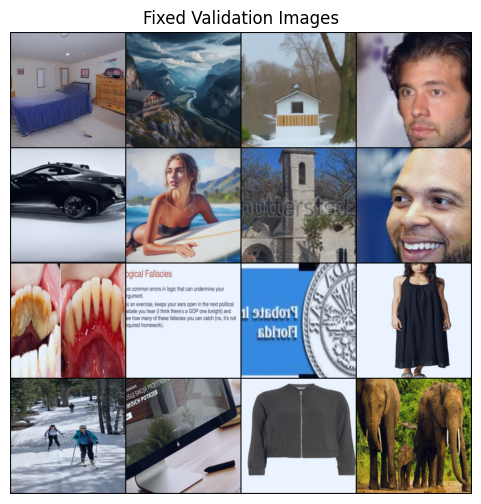

Fake: 002134.png
Fake: 018404.png
Fake: 032646.png
Fake: 001584.png
Fake: 011180.png
Fake: 002018.png
Fake: 029233.png
Fake: 027892.png
Real: 0020531.png
Real: 0016875.png
Real: 0024451.png
Real: 0005015.png
Real: 000000414170.jpg
Real: 0017916.png
Real: 0000770.png
Real: 000000346905.jpg


In [15]:
# SEED = 42
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)

grid_size = 4
num_images = grid_size * grid_size

if isinstance(val_dataset, torch.utils.data.Subset):
    subset = val_dataset
    base = val_dataset.dataset

    all_indices = subset.indices
    all_paths  = [base.samples[i][0] for i in all_indices]
    all_labels = [base.samples[i][1] for i in all_indices]

else:
    all_paths  = [p for p, l in val_dataset.samples]
    all_labels = [l for p, l in val_dataset.samples]

labels_tensor = torch.tensor(all_labels)

real_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]
fake_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]

half_num = num_images // 2
real_sample = real_indices[torch.randperm(len(real_indices))[:half_num]]
fake_sample = fake_indices[torch.randperm(len(fake_indices))[:half_num]]

subset_indices = torch.cat([real_sample, fake_sample])

if isinstance(val_dataset, torch.utils.data.Subset):
    base = val_dataset.dataset
    original_indices = [all_indices[i.item()] for i in subset_indices]

    fixed_images = torch.stack([base[i][0] for i in original_indices]).to(device)
    fixed_labels = torch.tensor([base[i][1] for i in original_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

else:
    fixed_images = torch.stack([val_dataset[i][0] for i in subset_indices]).to(device)
    fixed_labels = torch.tensor([val_dataset[i][1] for i in subset_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

grid_img = make_grid(fixed_images.cpu(), nrow=grid_size, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_img.numpy(), (1,2,0)))
plt.axis("off")
plt.title("Fixed Validation Images")
plt.show()

for path, lbl in zip(fixed_paths, fixed_labels):
    print(f"{'Real' if lbl==0 else 'Fake'}: {os.path.basename(path)}")


In [16]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_pbar = tqdm(train_loader, desc="Training", unit="batch")
    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
        train_acc = 100.0 * correct / total

        train_pbar.set_postfix({
            "Loss": f"{avg_loss:.4f}",
            "Train Acc": f"{train_acc:.2f}%"
        })

    avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
    train_acc = 100.0 * correct / total if total > 0 else 0.0
    return avg_loss, train_acc


def eval_accuracy(model, loader, device, desc="Evaluating"):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, unit="batch", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = 100.0 * correct / total if total > 0 else 0.0
    return acc


In [23]:
def sliding_window_training(
    model,
    criterion,
    optimizer,
    train_dataset,
    val_dataset,
    train_real_indices,
    train_fake_indices_by_w,
    val_real_indices,
    val_fake_indices_by_w,
    max_w,
    num_epochs_per_step,
    batch_size,
    device,
    num_workers=0
):
    history = []
    start_time = time.time()

    for k in range(0, max_w):  # last step is k=max_w-1 with next window = max_w
        print("\n" + "="*70)
        print(f"🔷 Sliding step {k}: train on w[0..{k}], validate on w{ k+1 }")
        print("="*70)

        past_windows = list(range(0, k+1))
        next_window  = k + 1
        all_up_to_next = list(range(0, max_w+1))

        # --- Build loaders ---
        train_loader, n_train = make_loader_for_windows(
            train_dataset,
            train_real_indices,
            train_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers
        )

        val_past_loader, n_val_past = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_next_loader, n_val_next = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            [next_window],
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_all_loader, n_val_all = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            all_up_to_next,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        print(f"Train: {n_train} samples (Real + Fake windows {past_windows})")
        print(f"Val past: {n_val_past} samples (windows {past_windows})")
        print(f"Val next: {n_val_next} samples (window {next_window})")
        print(f"Val all: {n_val_all} samples (windows {all_up_to_next})")

        # --- Train for num_epochs_per_step on current window setup ---
        for epoch in range(num_epochs_per_step):
            epoch_start_time = time.time()
            print(f"\n[Step {k}] Epoch {epoch+1}/{num_epochs_per_step}")
            train_loss, train_acc = train_one_epoch(
                model, train_loader, criterion, optimizer, device
            )

            # Three validations
            acc_past = eval_accuracy(model, val_past_loader, device, desc="Val past")
            acc_next = eval_accuracy(model, val_next_loader, device, desc="Val next")
            acc_all  = eval_accuracy(model, val_all_loader,  device, desc="Val all")

            print(
                f"[Step {k} | Epoch {epoch+1}] "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                f"ValPast: {acc_past:.2f}% | ValNext: {acc_next:.2f}% | ValAll: {acc_all:.2f}%"
            )

            history.append({
                "step": k,
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_past_acc": acc_past,
                "val_next_acc": acc_next,
                "val_all_acc": acc_all
            })
            total_epoch_minutes = (time.time() - epoch_start_time) / 60.0
            print(f"Total Epoch time: {total_epoch_minutes:.2f} minutes")

    total_minutes = (time.time() - start_time) / 60.0
    print(f"\nSliding-window training complete in {total_minutes:.2f} minutes.")
    return history


In [24]:
# # Training loop

# def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
#     best_val_acc = 0.0
#     start_time = time.time()

#     track_loss = []
#     track_train_acc = []
#     track_val_acc = []

#     for epoch in range(num_epochs):
#         model.train()
#         running_loss = 0.0
#         correct = 0
#         total = 0

#         print(f"\n🔹 Epoch {epoch+1}/{num_epochs}")

#         # Wrap train loader with tqdm
#         train_pbar = tqdm(train_loader, desc="Training", unit="batch")
#         for images, labels in train_pbar:
#             images, labels = images.to(device), labels.to(device)
#             optimizer.zero_grad()

#             outputs = model(images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#             running_loss += loss.item()
#             _, predicted = outputs.max(1)
#             total += labels.size(0)
#             correct += predicted.eq(labels).sum().item()

#             train_acc = 100 * correct / total
#             avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)

#             # Live update progress bar
#             train_pbar.set_postfix({
#                 "Loss": f"{avg_loss:.4f}",
#                 "Train Acc": f"{train_acc:.2f}%"
#             })

#         # Validation
#         model.eval()
#         val_correct = 0
#         val_total = 0
#         val_pbar = tqdm(val_loader, desc="Validating", unit="batch", leave=False)
#         with torch.no_grad():
#             for images, labels in val_pbar:
#                 images, labels = images.to(device), labels.to(device)
#                 outputs = model(images)
#                 _, predicted = outputs.max(1)
#                 val_total += labels.size(0)
#                 val_correct += predicted.eq(labels).sum().item()

#             #-------------images
#             outputs_grid = model(fixed_images)
#             preds_grid = torch.argmax(outputs_grid, dim=1)

#         val_acc = 100 * val_correct / val_total

#         label_names = ['Real', 'Fake']
#         true_names = [label_names[l.item()] for l in fixed_labels]
#         pred_names = [label_names[p.item()] for p in preds_grid]

#         # Create the figure
#         fig, axs = plt.subplots(3, 1, figsize=(8, 8))

#         # Row 1: Image grid
#         grid_img = make_grid(fixed_images.cpu(), nrow=grid_size, normalize=True)
#         axs[0].imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
#         axs[0].set_title("Validation Samples")
#         axs[0].axis("off")

#         # Image dimensions for positioning labels
#         img_w = grid_img.shape[2] // grid_size
#         img_h = grid_img.shape[1] // grid_size

#         # Row 2: True labels (white background + text)
#         axs[1].imshow(np.ones((img_h * grid_size, img_w * grid_size, 3)))
#         axs[1].set_title("True Labels")
#         axs[1].axis("off")
#         for i, lbl in enumerate(true_names):
#             axs[1].text(
#                 (i % grid_size + 0.5) * img_w,
#                 (i // grid_size + 0.5) * img_h,
#                 lbl,
#                 ha='center', va='center', fontsize=14, color='black'
#             )

#         # Row 3: Predicted labels (green/red text for correctness)
#         axs[2].imshow(np.ones((img_h * grid_size, img_w * grid_size, 3)))
#         axs[2].set_title("Predicted Labels")
#         axs[2].axis("off")
#         for i, lbl in enumerate(pred_names):
#             color = 'green' if lbl == true_names[i] else 'red'
#             axs[2].text(
#                 (i % grid_size + 0.5) * img_w,
#                 (i // grid_size + 0.5) * img_h,
#                 lbl,
#                 ha='center', va='center', fontsize=14, color=color
#             )

#         plt.tight_layout()
#         plt.show()

#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             torch.save(model.state_dict(), "best_resnet50_baseline.pth")

#         print(f"Epoch {epoch+1}/{num_epochs} "
#               f"Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        
#         track_loss.append(avg_loss)
#         track_train_acc.append(train_acc)
#         track_val_acc.append(val_acc)

#     print(f"\nTraining complete in {(time.time() - start_time)/60:.2f} minutes.")
#     print(f"Best validation accuracy: {best_val_acc:.2f}%")
    
#     plot_loss_and_acc(track_loss, track_train_acc, track_val_acc)

#     return track_loss, track_train_acc, track_val_acc

## Temporal Run 11/22 1500

In [27]:
num_epochs_per_step = 5

history = sliding_window_training(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    train_real_indices=train_real_indices,
    train_fake_indices_by_w=train_fake_indices_by_w,
    val_real_indices=val_real_indices,
    val_fake_indices_by_w=val_fake_indices_by_w,
    max_w=max_w,
    num_epochs_per_step=num_epochs_per_step,
    batch_size=batch_size,
    device=device,
    num_workers=0
)



🔷 Sliding step 0: train on w[0..0], validate on w1
Train: 63964 samples (Real + Fake windows [0])
Val past: 15715 samples (windows [0])
Val next: 15774 samples (window 1)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 0] Epoch 1/5


Training: 100%|██████████| 1999/1999 [07:45<00:00,  4.29batch/s, Loss=0.2142, Train Acc=99.21%]


[Step 0 | Epoch 1] Train Loss: 0.2142 | Train Acc: 99.21% | ValPast: 99.19% | ValNext: 95.21% | ValAll: 73.86%
Total Epoch time: 16.07 minutes

[Step 0] Epoch 2/5


Training: 100%|██████████| 1999/1999 [09:11<00:00,  3.63batch/s, Loss=0.2135, Train Acc=99.25%]


[Step 0 | Epoch 2] Train Loss: 0.2135 | Train Acc: 99.25% | ValPast: 99.17% | ValNext: 94.84% | ValAll: 72.42%
Total Epoch time: 16.36 minutes

[Step 0] Epoch 3/5


...

[Step 7 | Epoch 3] Train Loss: 0.2681 | Train Acc: 95.92% | ValPast: 95.33% | ValNext: 92.36% | ValAll: 93.68%
Total Epoch time: 22.40 minutes

[Step 7] Epoch 4/5


Training: 100%|██████████| 3399/3399 [13:15<00:00,  4.27batch/s, Loss=0.2652, Train Acc=96.12%]


[Step 7 | Epoch 4] Train Loss: 0.2652 | Train Acc: 96.12% | ValPast: 94.69% | ValNext: 90.95% | ValAll: 93.86%
Total Epoch time: 22.10 minutes

[Step 7] Epoch 5/5


Training: 100%|██████████| 3399/3399 [13:18<00:00,  4.26batch/s, Loss=0.2624, Train Acc=96.28%]
                                                              

[Step 7 | Epoch 5] Train Loss: 0.2624 | Train Acc: 96.28% | ValPast: 94.86% | ValNext: 92.20% | ValAll: 93.89%
Total Epoch time: 22.14 minutes

Sliding-window training complete in 892.96 minutes.


In [28]:
hist_df = pd.DataFrame(history)
print(hist_df.head())


   step  epoch  train_loss  train_acc  val_past_acc  val_next_acc  val_all_acc
0     0      1    0.214164  99.208930     99.185492     95.213643    73.856740
1     0      2    0.213539  99.246451     99.166402     94.839609    72.417078
2     0      3    0.214123  99.177662     99.510022     94.922024    71.764291
3     0      4    0.212115  99.316803     99.268215     95.416508    75.017643
4     0      5    0.211604  99.337127     99.306395     94.364144    70.035286


<Axes: >

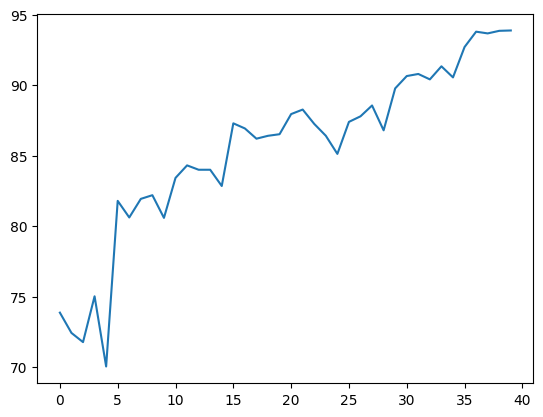

In [31]:
hist_df['val_all_acc'].plot()

<Axes: >

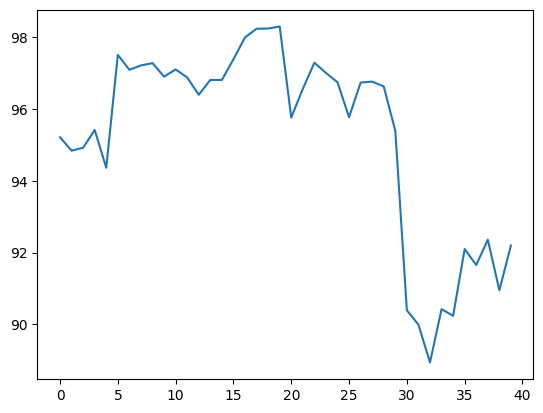

In [33]:
hist_df['val_next_acc'].plot()

<Axes: >

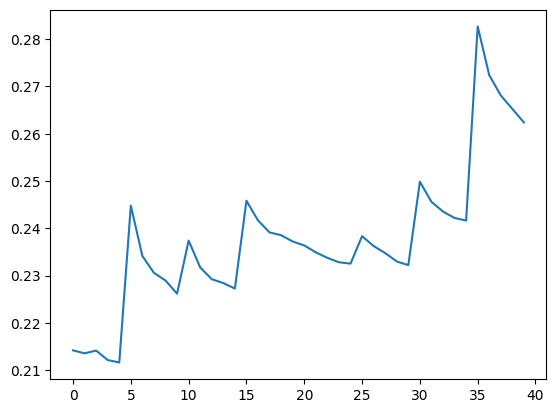

In [32]:
hist_df['train_loss'].plot()

## Run with 1 epoch 11/23

In [34]:
num_epochs_per_step = 1

history_1 = sliding_window_training(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    train_real_indices=train_real_indices,
    train_fake_indices_by_w=train_fake_indices_by_w,
    val_real_indices=val_real_indices,
    val_fake_indices_by_w=val_fake_indices_by_w,
    max_w=max_w,
    num_epochs_per_step=num_epochs_per_step,
    batch_size=batch_size,
    device=device,
    num_workers=0
)


🔷 Sliding step 0: train on w[0..0], validate on w1
Train: 63964 samples (Real + Fake windows [0])
Val past: 15715 samples (windows [0])
Val next: 15774 samples (window 1)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 0] Epoch 1/1


Training: 100%|██████████| 1999/1999 [09:01<00:00,  3.69batch/s, Loss=0.2097, Train Acc=99.44%]


[Step 0 | Epoch 1] Train Loss: 0.2097 | Train Acc: 99.44% | ValPast: 99.56% | ValNext: 97.54% | ValAll: 82.19%
Total Epoch time: 16.34 minutes

🔷 Sliding step 1: train on w[0..1], validate on w2
Train: 70419 samples (Real + Fake windows [0, 1])
Val past: 17319 samples (windows [0, 1])
Val next: 15694 samples (window 2)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 1] Epoch 1/1


Training: 100%|██████████| 2201/2201 [11:02<00:00,  3.32batch/s, Loss=0.2192, Train Acc=98.87%]


[Step 1 | Epoch 1] Train Loss: 0.2192 | Train Acc: 98.87% | ValPast: 98.65% | ValNext: 98.27% | ValAll: 85.19%
Total Epoch time: 18.43 minutes

🔷 Sliding step 2: train on w[0..2], validate on w3
Train: 76920 samples (Real + Fake windows [0, 1, 2])
Val past: 18843 samples (windows [0, 1, 2])
Val next: 15740 samples (window 3)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 2] Epoch 1/1


...

[Step 5 | Epoch 1] Train Loss: 0.2294 | Train Acc: 98.30% | ValPast: 97.89% | ValNext: 96.47% | ValAll: 90.43%
Total Epoch time: 21.00 minutes

🔷 Sliding step 6: train on w[0..6], validate on w7
Train: 102354 samples (Real + Fake windows [0, 1, 2, 3, 4, 5, 6])
Val past: 25166 samples (windows [0, 1, 2, 3, 4, 5, 6])
Val next: 15757 samples (window 7)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 6] Epoch 1/1


Training: 100%|██████████| 3199/3199 [15:06<00:00,  3.53batch/s, Loss=0.2393, Train Acc=97.74%]


[Step 6 | Epoch 1] Train Loss: 0.2393 | Train Acc: 97.74% | ValPast: 96.92% | ValNext: 90.54% | ValAll: 91.82%
Total Epoch time: 24.29 minutes

🔷 Sliding step 7: train on w[0..7], validate on w8
Train: 108741 samples (Real + Fake windows [0, 1, 2, 3, 4, 5, 6, 7])
Val past: 26753 samples (windows [0, 1, 2, 3, 4, 5, 6, 7])
Val next: 15757 samples (window 8)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 7] Epoch 1/1


Training: 100%|██████████| 3399/3399 [18:09<00:00,  3.12batch/s, Loss=0.2697, Train Acc=95.81%]
                                                              

[Step 7 | Epoch 1] Train Loss: 0.2697 | Train Acc: 95.81% | ValPast: 95.23% | ValNext: 92.05% | ValAll: 94.43%
Total Epoch time: 26.79 minutes

Sliding-window training complete in 161.94 minutes.
